In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Bin_size = 0.01 # 10 ms bins
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]
Total trials: 289
Stim trials: 146
Catch trials: 143
Total spikes in AP: 431640.0


# CREATION MATRICES DES ACTIVITE POUR CHAQUE AMP ET CATCH (BRUIT)

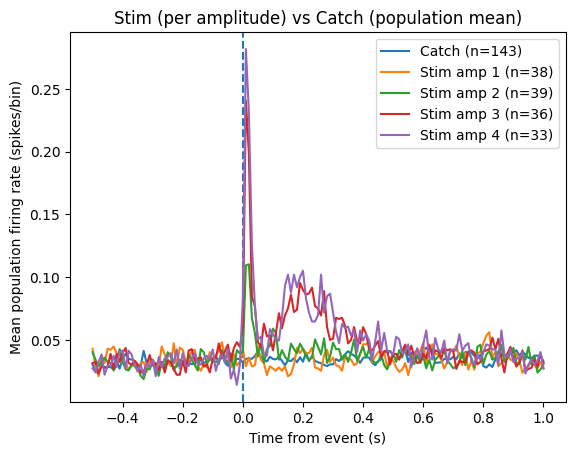

In [4]:
amps_stim = [1,2,3,4]

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))  # (n_neurons, W)
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)  # (n_trials, n_neurons, W)

# event-triggered mean
def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

# stim times par amplitude
stim_sel = tr["whisker_stim_time"].notna() & tr["whisker_stim_amplitude"].isin(amps_stim)

Stim_times_by_amp = {
    a: np.sort(tr.loc[stim_sel & (tr["whisker_stim_amplitude"] == a), "whisker_stim_time"].to_numpy())
    for a in amps_stim
}

catch_sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
Catch_times = np.sort((tr.loc[catch_sel, "no_stim_time"]).to_numpy())

pre_bins, post_bins = 50, 100
time_axis = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size

CATCH_MTRX, n_catch = event_triggered_mean(AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, pre_bins, post_bins)

plt.figure()
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label=f"Catch (n={n_catch})")
plt.axvline(0, linestyle="--")

STM_by_amp = {}
for a in amps_stim:
    STM_by_amp[a], n_st = event_triggered_mean(AP_Bin_Matrx, Stim_times_by_amp[a], AP_Bin_Resolution, pre_bins, post_bins)
    plt.plot(time_axis, STM_by_amp[a].mean(axis=0), label=f"Stim amp {a} (n={n_st})")


plt.xlabel("Time from event (s)")
plt.ylabel("Mean population firing rate (spikes/bin)")
plt.title("Stim (per amplitude) vs Catch (population mean)")
plt.legend()
plt.show()

# Matrice de Coding Direction

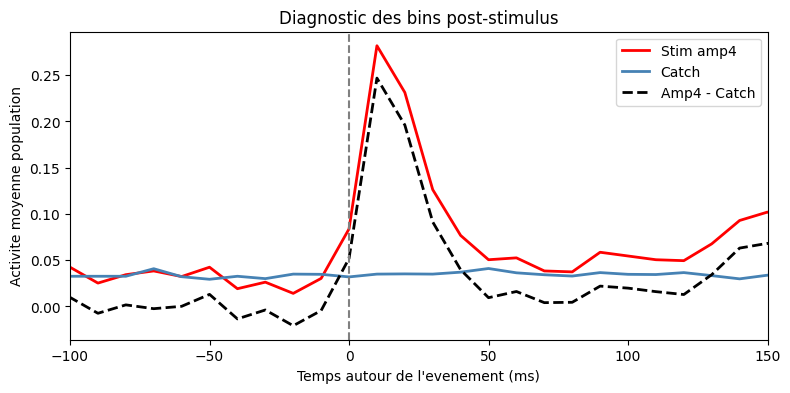

In [5]:
# Diagnostic simple : reponse moyenne amp4 vs catch sur les bins apres l'evenement

pre_bins_cd = pre_bins
time_ms = (np.arange(STM_by_amp[4].shape[1]) - pre_bins_cd) * Bin_size * 1000

mean_amp4_pop = STM_by_amp[4].mean(axis=0)
mean_catch_pop = CATCH_MTRX.mean(axis=0)
diff_pop = mean_amp4_pop - mean_catch_pop

plt.figure(figsize=(9, 4))
plt.plot(time_ms, mean_amp4_pop, label="Stim amp4", color="red", lw=2)
plt.plot(time_ms, mean_catch_pop, label="Catch", color="steelblue", lw=2)
plt.plot(time_ms, diff_pop, label="Amp4 - Catch", color="black", lw=2, linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlim(-100, 150)
plt.xlabel("Temps autour de l'evenement (ms)")
plt.ylabel("Activite moyenne population")
plt.title("Diagnostic des bins post-stimulus")
plt.legend()
plt.show()

In [20]:
# Construction d'une matrice de Coding Direction multi-bin
# Chaque colonne = un vecteur CD pour un bin donne apres le stimulus

n_cd_bins = 8
cd_start_bin = pre_bins
cd_offsets = np.arange(n_cd_bins)

CD_matrix = []
ref_proj_vec = []

for off in cd_offsets:
    idx = cd_start_bin + off

    pop_stim = STM_by_amp[4][:, idx]
    pop_catch = CATCH_MTRX[:, idx]

    cd = pop_stim - pop_catch
    cd = cd / (np.linalg.norm(cd) + 1e-12)

    CD_matrix.append(cd)

    ref_proj = float(cd @ pop_stim)
    ref_proj_vec.append(ref_proj)

CD_matrix = np.stack(CD_matrix, axis=1)
ref_proj_vec = np.array(ref_proj_vec)

print("CD_matrix shape :", CD_matrix.shape)
print("ref_proj_vec shape :", ref_proj_vec.shape)
print("Nombre de bins CD :", n_cd_bins)

CD_matrix shape : (30, 8)
ref_proj_vec shape : (8,)
Nombre de bins CD : 8


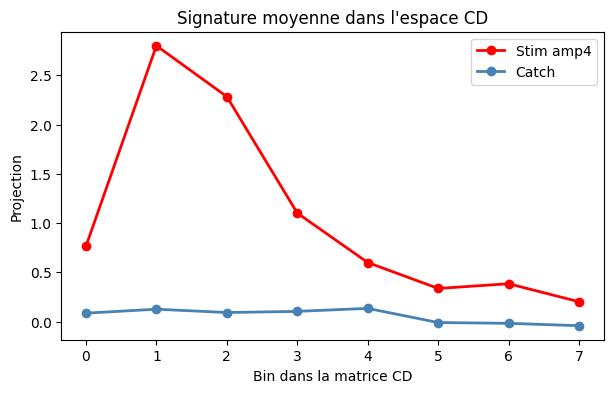

In [21]:
# Projections de la reponse moyenne amp4 et catch sur chaque CD

stim_proj = []
catch_proj = []

for k, off in enumerate(cd_offsets):
    idx = cd_start_bin + off
    stim_proj.append(float(CD_matrix[:, k] @ STM_by_amp[4][:, idx]))
    catch_proj.append(float(CD_matrix[:, k] @ CATCH_MTRX[:, idx]))

stim_proj = np.array(stim_proj)
catch_proj = np.array(catch_proj)

plt.figure(figsize=(7, 4))
plt.plot(cd_offsets, stim_proj, "-o", color="red", lw=2, label="Stim amp4")
plt.plot(cd_offsets, catch_proj, "-o", color="steelblue", lw=2, label="Catch")
plt.xlabel("Bin dans la matrice CD")
plt.ylabel("Projection")
plt.title("Signature moyenne dans l'espace CD")
plt.legend()
plt.show()

proj_cont shape : (388281, 8)
dist_cont shape : (388281,)


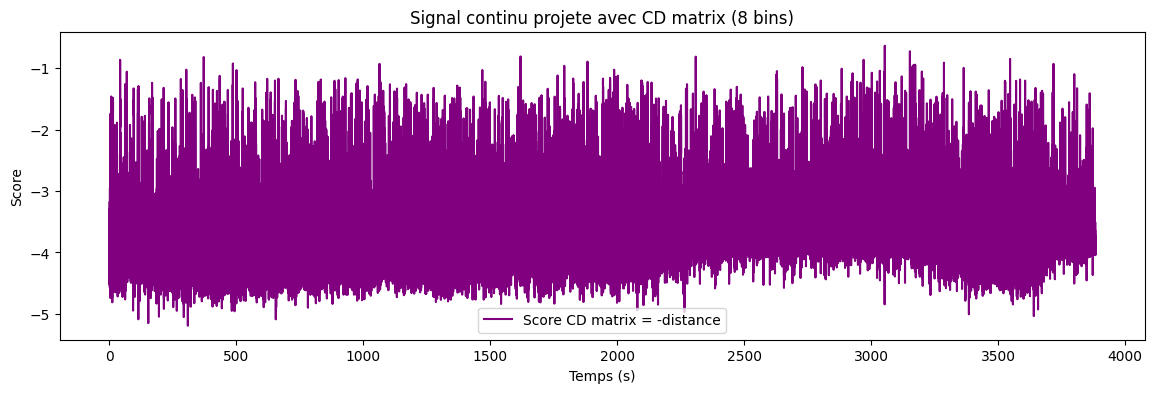

In [22]:
# Application de la matrice CD au signal continu
# On avance de 1 bin en 1 bin
# A chaque temps t, on prend n_cd_bins consecutifs et on les projette sur les CD correspondants

def apply_cd_matrix_continuous(AP_Bin_Matrx, CD_matrix, ref_proj_vec, cd_offsets):
    n_neurons, T = AP_Bin_Matrx.shape
    max_off = np.max(cd_offsets)

    valid_t = np.arange(0, T - max_off)

    proj_cont = np.zeros((len(valid_t), len(cd_offsets)), dtype=np.float32)
    dist_cont = np.zeros(len(valid_t), dtype=np.float32)

    for i, t in enumerate(valid_t):
        this_proj = np.zeros(len(cd_offsets), dtype=np.float32)

        for k, off in enumerate(cd_offsets):
            x = AP_Bin_Matrx[:, t + off]
            cd = CD_matrix[:, k]
            this_proj[k] = cd @ x

        proj_cont[i] = this_proj
        dist_cont[i] = np.linalg.norm(this_proj - ref_proj_vec)

    return valid_t, proj_cont, dist_cont

valid_t, proj_cont, dist_cont = apply_cd_matrix_continuous(
    AP_Bin_Matrx,
    CD_matrix,
    ref_proj_vec,
    cd_offsets
)

t_cont = valid_t * Bin_size
score_cd_matrix = -dist_cont

print("proj_cont shape :", proj_cont.shape)
print("dist_cont shape :", dist_cont.shape)

# Score continu
# Distance faible = ressemble au stimulus
# Donc score = -distance

plt.figure(figsize=(14, 4))
plt.plot(t_cont, score_cd_matrix, color="purple", lw=1.5, label="Score CD matrix = -distance")
plt.xlabel("Temps (s)")
plt.ylabel("Score")
plt.title(f"Signal continu projete avec CD matrix ({n_cd_bins} bins)")
plt.legend()
plt.show()

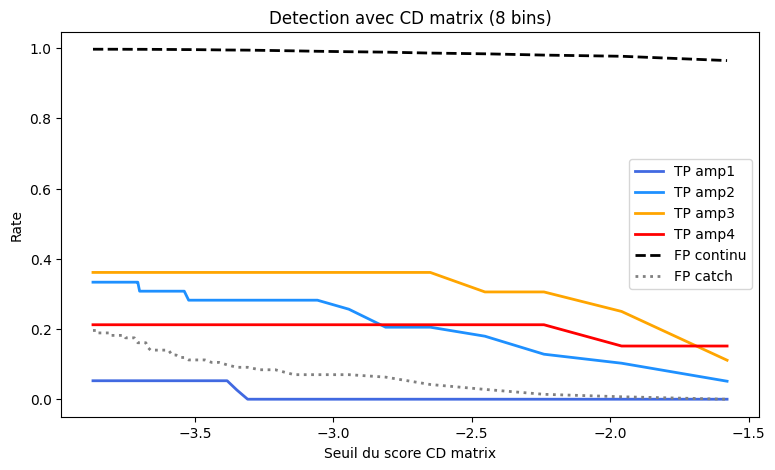

In [23]:
# Detection sur signal continu via score CD matrix

tol_post = 0.05
refractory_s = 0.2

t_start = float(tr["start_time"].min())
t_end = float(tr["stop_time"].max())

def detect_peaks_score(score, t, thr, refractory_s, Bin_size, t_start, t_end):
    mask = (t >= t_start) & (t <= t_end) & (score > thr)
    idx = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)

    cuts = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)

    min_b = int(np.round(refractory_s / Bin_size))
    keep = [peaks[0]]

    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p

    return t[np.array(keep, dtype=int)]

in_range = (t_cont >= t_start) & (t_cont <= t_end)
ths = np.percentile(score_cd_matrix[in_range], np.linspace(50, 99.9, 80))

all_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in amps_stim]))
n_catch_trials = len(Catch_times)

tp_curves = {a: [] for a in amps_stim}
fp_cont_curve = []
fp_catch_curve = []

for thr in ths:
    det_t = detect_peaks_score(score_cd_matrix, t_cont, thr, refractory_s, Bin_size, t_start, t_end)
    n_det = max(len(det_t), 1)

    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    fp_cont_curve.append(np.sum(~in_win_any) / n_det)

    hits_catch = sum(
        np.any((det_t >= ct) & (det_t <= ct + tol_post))
        for ct in Catch_times
    )
    fp_catch_curve.append(hits_catch / max(n_catch_trials, 1))

    for a in amps_stim:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_curves[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_curves = {a: np.array(tp_curves[a]) for a in amps_stim}
fp_cont_curve = np.array(fp_cont_curve)
fp_catch_curve = np.array(fp_catch_curve)

# Couleurs pour les différentes amplitudes de stimulus

colors_amp = {
    0: "gray",
    1: "royalblue",
    2: "dodgerblue",
    3: "orange",
    4: "red"
}

plt.figure(figsize=(9, 5))
for a in amps_stim:
    plt.plot(ths, tp_curves[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
plt.plot(ths, fp_cont_curve, color="black", lw=2, linestyle="--", label="FP continu")
plt.plot(ths, fp_catch_curve, color="gray", lw=2, linestyle=":", label="FP catch")
plt.xlabel("Seuil du score CD matrix")
plt.ylabel("Rate")
plt.title(f"Detection avec CD matrix ({n_cd_bins} bins)")
plt.legend()
plt.show()

In [24]:
# Selection d'un seuil fixe pour etudier les faux positifs
# Ici on prend le meilleur seuil selon TP amp4 - FP continu

best_i = np.argmax(tp_curves[4] - fp_cont_curve)
best_thr = ths[best_i]

det_t = detect_peaks_score(score_cd_matrix, t_cont, best_thr, refractory_s, Bin_size, t_start, t_end)

in_win_any = np.zeros(len(det_t), dtype=bool)
for st in all_stim_times:
    in_win_any |= (det_t >= st) & (det_t <= st + tol_post)

fp_times = det_t[~in_win_any]

tp_times_by_amp = {}
for a in amps_stim:
    in_win = np.zeros(len(det_t), dtype=bool)
    for st in Stim_times_by_amp[a]:
        in_win |= (det_t >= st) & (det_t <= st + tol_post)
    tp_times_by_amp[a] = det_t[in_win]

print(f"Best threshold : {best_thr:.3f}")
print(f"Nombre total de detections : {len(det_t)}")
print(f"Nombre de bursts spontanes candidats : {len(fp_times)}")
for a in amps_stim:
    print(f"TP amp{a} : {len(tp_times_by_amp[a])}")

Best threshold : -2.239
Nombre total de detections : 1157
Nombre de bursts spontanes candidats : 1134
TP amp1 : 0
TP amp2 : 5
TP amp3 : 11
TP amp4 : 7


In [25]:
# Comparaison directe entre vrais stimuli et bursts spontanes detectes
# On utilise la meme representation multi-bin que la CD matrix

pre = 10
post = 30
t_win = (np.arange(pre + post) - pre) * Bin_size

def extract_windows(times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post):
    segs = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - pre < 0 or pt + post > AP_Bin_Matrx.shape[1]:
            continue
        segs.append(AP_Bin_Matrx[:, pt - pre:pt + post])
    return np.array(segs) if segs else None

def multibin_proj_and_dist(segs, CD_matrix, ref_proj_vec, pre, cd_offsets):
    if segs is None:
        return None, None

    proj = []
    dist = []

    for s in segs:
        this_proj = []
        for k, off in enumerate(cd_offsets):
            idx = pre + off
            x = s[:, idx]
            this_proj.append(float(CD_matrix[:, k] @ x))
        this_proj = np.array(this_proj)
        proj.append(this_proj)
        dist.append(float(np.linalg.norm(this_proj - ref_proj_vec)))

    return np.array(proj), np.array(dist)

segs_fp = extract_windows(fp_times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post)
proj_fp, dist_fp = multibin_proj_and_dist(segs_fp, CD_matrix, ref_proj_vec, pre, cd_offsets)

proj_by_amp = {}
dist_by_amp = {}

for a in amps_stim:
    segs_a = extract_windows(tp_times_by_amp[a], AP_Bin_Matrx, AP_Bin_Resolution, pre, post)
    proj_by_amp[a], dist_by_amp[a] = multibin_proj_and_dist(segs_a, CD_matrix, ref_proj_vec, pre, cd_offsets)

for a in amps_stim:
    if dist_by_amp[a] is not None and len(dist_by_amp[a]) > 0:
        print(f"Distance amp{a} : {dist_by_amp[a].mean():.3f} ± {dist_by_amp[a].std():.3f}")

if dist_fp is not None and len(dist_fp) > 0:
    print(f"Distance FP : {dist_fp.mean():.3f} ± {dist_fp.std():.3f}")

Distance amp2 : 1.725 ± 0.248
Distance amp3 : 1.611 ± 0.390
Distance amp4 : 1.492 ± 0.338
Distance FP : 1.781 ± 0.313


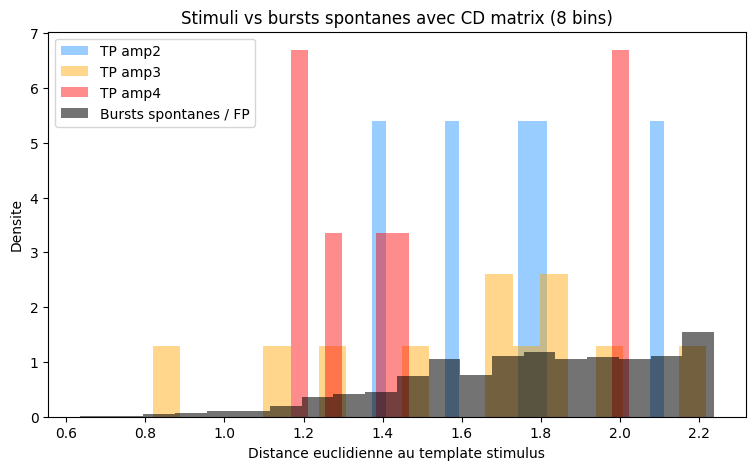

In [26]:
# Histogramme des distances au template stimulus dans l'espace CD multi-bin

plt.figure(figsize=(9, 5))

for a in amps_stim:
    if dist_by_amp[a] is not None and len(dist_by_amp[a]) > 0:
        plt.hist(dist_by_amp[a], bins=20, alpha=0.45, density=True, color=colors_amp[a], label=f"TP amp{a}")

if dist_fp is not None and len(dist_fp) > 0:
    plt.hist(dist_fp, bins=20, alpha=0.55, density=True, color="black", label="Bursts spontanes / FP")

# Couleurs pour les différentes amplitudes de stimulus

colors_amp = {
    0: "gray",
    1: "royalblue",
    2: "dodgerblue",
    3: "orange",
    4: "red"
}

plt.xlabel("Distance euclidienne au template stimulus")
plt.ylabel("Densite")
plt.title(f"Stimuli vs bursts spontanes avec CD matrix ({n_cd_bins} bins)")
plt.legend()
plt.show()

   n_cd_bins  best_tp4   best_fp  best_metric  best_thr
0          1  0.181818  0.997382    -0.815564 -0.218356
1          3  0.242424  0.975775    -0.733351 -1.823876
2          5  0.212121  0.981728    -0.769606 -2.175901
3          8  0.212121  0.980121    -0.768000 -2.239110
4         10  0.212121  0.984733    -0.772612 -2.530688


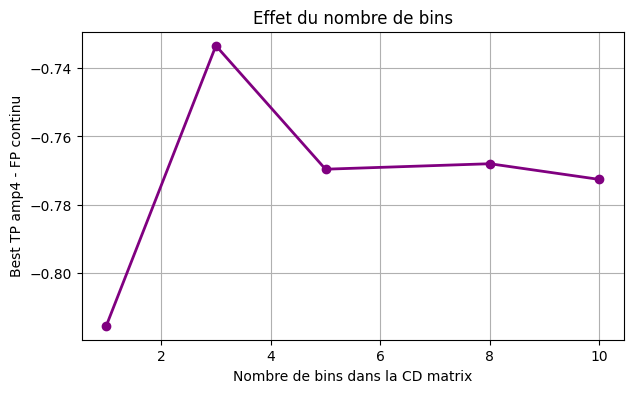

In [27]:
# Effet du nombre de bins dans la matrice CD
# On regarde le meilleur score TP amp4 - FP continu

n_cd_bins_list = [1, 3, 5, 8, 10]
best_rows = []

for n_cd_bins_test in n_cd_bins_list:
    cd_offsets_test = np.arange(n_cd_bins_test)

    CD_matrix_test = []
    ref_proj_test = []

    for off in cd_offsets_test:
        idx = pre_bins + off

        pop_stim = STM_by_amp[4][:, idx]
        pop_catch = CATCH_MTRX[:, idx]

        cd = pop_stim - pop_catch
        cd = cd / (np.linalg.norm(cd) + 1e-12)

        CD_matrix_test.append(cd)
        ref_proj_test.append(float(cd @ pop_stim))

    CD_matrix_test = np.stack(CD_matrix_test, axis=1)
    ref_proj_test = np.array(ref_proj_test)

    valid_t_test, proj_cont_test, dist_cont_test = apply_cd_matrix_continuous(
        AP_Bin_Matrx,
        CD_matrix_test,
        ref_proj_test,
        cd_offsets_test
    )

    t_cont_test = valid_t_test * Bin_size
    score_test = -dist_cont_test

    in_range = (t_cont_test >= t_start) & (t_cont_test <= t_end)
    ths_test = np.percentile(score_test[in_range], np.linspace(50, 99.9, 80))

    tp4_curve = []
    fp_curve = []

    for thr in ths_test:
        det_t = detect_peaks_score(score_test, t_cont_test, thr, refractory_s, Bin_size, t_start, t_end)
        n_det = max(len(det_t), 1)

        in_win_any = np.zeros(len(det_t), dtype=bool)
        for st in all_stim_times:
            in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
        fp_curve.append(np.sum(~in_win_any) / n_det)

        hits4 = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[4]
        )
        tp4_curve.append(hits4 / max(len(Stim_times_by_amp[4]), 1))

    tp4_curve = np.array(tp4_curve)
    fp_curve = np.array(fp_curve)

    best_idx = np.argmax(tp4_curve - fp_curve)

    best_rows.append({
        "n_cd_bins": n_cd_bins_test,
        "best_tp4": tp4_curve[best_idx],
        "best_fp": fp_curve[best_idx],
        "best_metric": (tp4_curve - fp_curve)[best_idx],
        "best_thr": ths_test[best_idx]
    })

best_df = pd.DataFrame(best_rows)
print(best_df)

plt.figure(figsize=(7, 4))
plt.plot(best_df["n_cd_bins"], best_df["best_metric"], "-o", color="purple", lw=2)
plt.xlabel("Nombre de bins dans la CD matrix")
plt.ylabel("Best TP amp4 - FP continu")
plt.title("Effet du nombre de bins")
plt.grid(True)
plt.show()